In [1]:
import pandas as pd
import glob
import os

# 원본 연도별 파일만 정확히 지정 (가공된 결과 파일은 제외)
file_paths = glob.glob("../data/gimhae_20[0-9][0-9].csv")
print("찾은 파일:", file_paths)

df_list = [pd.read_csv(f, encoding="cp949") for f in file_paths]
df = pd.concat(df_list, ignore_index=True)

print("전체 행 개수:", len(df))
df.head()

찾은 파일: ['../data\\gimhae_2023.csv', '../data\\gimhae_2024.csv', '../data\\gimhae_2025.csv', '../data\\gimhae_2026.csv']
전체 행 개수: 232261


,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유
0,기준 : 일간(20230101~20231231),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230101.0,HD현대오일뱅크,셀프,0.0,1518.0,1658.0,1600.0
2,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230102.0,HD현대오일뱅크,셀프,0.0,1518.0,1658.0,1600.0
3,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230103.0,HD현대오일뱅크,셀프,0.0,1518.0,1658.0,1600.0
4,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230104.0,HD현대오일뱅크,셀프,0.0,1498.0,1638.0,1600.0


In [2]:
# "기간"이 NaN인 행(헤더 설명 줄)은 실제 데이터가 아니므로 제거
before = len(df)
df = df.dropna(subset=["기간"]).copy()
print(f"제거 전: {before}행 -> 제거 후: {len(df)}행")
df.head()

제거 전: 232261행 -> 제거 후: 232257행


,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유
1,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230101.0,HD현대오일뱅크,셀프,0.0,1518.0,1658.0,1600.0
2,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230102.0,HD현대오일뱅크,셀프,0.0,1518.0,1658.0,1600.0
3,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230103.0,HD현대오일뱅크,셀프,0.0,1518.0,1658.0,1600.0
4,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230104.0,HD현대오일뱅크,셀프,0.0,1498.0,1638.0,1600.0
5,A0029718,경남 김해시,(주)가온에너지 자이언츠주유소,경남 김해시 칠산로 213 (이동),20230105.0,HD현대오일뱅크,셀프,0.0,1487.0,1617.0,1600.0


In [3]:
# 필요한 열만 선택: 기간(날짜), 휘발유(가격)
df2 = df[["기간", "휘발유"]].copy()
df2.columns = ["date", "gas_price"]

# 날짜 형식 변환 (20230101.0 -> 2023-01-01)
df2["date"] = df2["date"].astype(int).astype(str)
df2["date"] = pd.to_datetime(df2["date"], format="%Y%m%d")

df2.head()

,date,gas_price
1,2023-01-01,1518.0
2,2023-01-02,1518.0
3,2023-01-03,1518.0
4,2023-01-04,1498.0
5,2023-01-05,1487.0


In [4]:
# 0원은 "휘발유 미취급 주유소"를 의미하므로 결측치로 처리
before_zero = (df2["gas_price"] == 0).sum()
df2["gas_price"] = df2["gas_price"].replace(0, pd.NA)

print(f"0원(결측 처리 대상) 개수: {before_zero}")
print(f"전체 행: {len(df2)}")

0원(결측 처리 대상) 개수: 1784
전체 행: 232257


In [5]:
# 날짜별로 여러 주유소의 휘발유 가격 평균 계산 (NaN은 자동 제외됨)
daily_avg = df2.groupby("date")["gas_price"].mean().reset_index()
daily_avg.columns = ["date", "value"]
daily_avg["value"] = daily_avg["value"].round(1)

print("최종 데이터 개수:", len(daily_avg))
daily_avg.head()

최종 데이터 개수: 1368


,date,value
0,2023-01-01,1515.1
1,2023-01-02,1524.9
2,2023-01-03,1530.4
3,2023-01-04,1534.7
4,2023-01-05,1534.7


In [6]:
daily_avg.tail()

,date,value
1363,2026-09-25,1837.4
1364,2026-09-26,1837.6
1365,2026-09-27,1838.3
1366,2026-09-28,1841.3
1367,2026-09-29,1840.2


In [7]:
print("기간:", daily_avg["date"].min().date(), "~", daily_avg["date"].max().date())
print("총 일수:", len(daily_avg))

full_range = pd.date_range(daily_avg["date"].min(), daily_avg["date"].max())
missing_dates = full_range.difference(daily_avg["date"])
print("누락된 날짜 개수:", len(missing_dates))
if len(missing_dates) > 0:
    print(missing_dates[:10])  # 처음 10개만 미리보기

기간: 2023-01-01 ~ 2026-09-29
총 일수: 1368
누락된 날짜 개수: 0


In [8]:
daily_avg.to_csv("../data/gimhae_gasoline_daily.csv", index=False, encoding="utf-8-sig")
print("저장 완료!")

저장 완료!


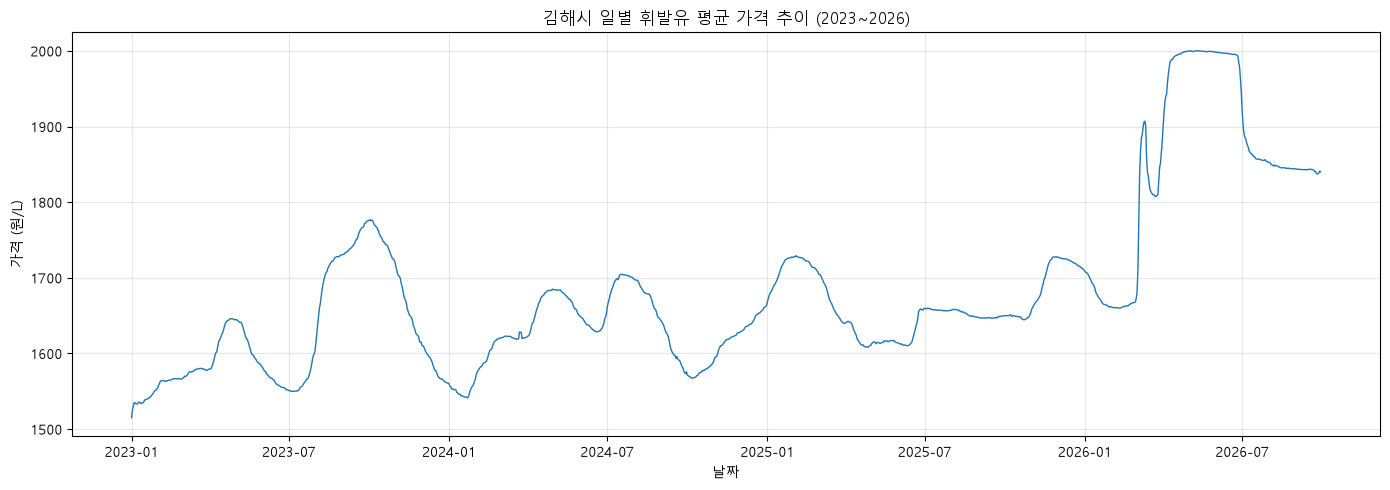

In [9]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 기본 폰트)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(14, 5))
plt.plot(daily_avg["date"], daily_avg["value"], linewidth=1)
plt.title("김해시 일별 휘발유 평균 가격 추이 (2023~2026)")
plt.xlabel("날짜")
plt.ylabel("가격 (원/L)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../notebook/01_price_trend.png", dpi=150)
plt.show()

In [10]:
# 7일, 30일 이동평균 계산
daily_avg["ma7"] = daily_avg["value"].rolling(window=7).mean()
daily_avg["ma30"] = daily_avg["value"].rolling(window=30).mean()

daily_avg.tail(10)

,date,value,ma7,ma30
1358,2026-09-20,1843.0,1843.300000,1843.673333
1359,2026-09-21,1842.2,1843.200000,1843.583333
1360,2026-09-22,1840.8,1842.814286,1843.456667
1361,2026-09-23,1840.9,1842.428571,1843.320000
1362,2026-09-24,1838.1,1841.642857,1843.106667
1363,2026-09-25,1837.4,1840.814286,1842.880000
1364,2026-09-26,1837.6,1840.000000,1842.660000
1365,2026-09-27,1838.3,1839.328571,1842.453333
1366,2026-09-28,1841.3,1839.200000,1842.356667
1367,2026-09-29,1840.2,1839.114286,1842.223333


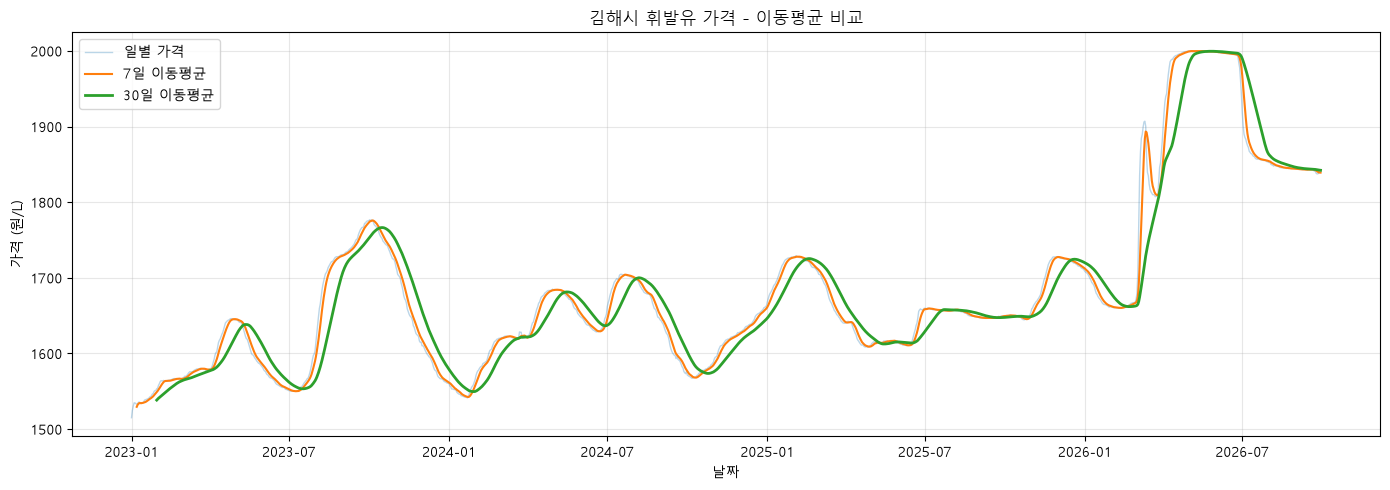

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(daily_avg["date"], daily_avg["value"], alpha=0.3, label="일별 가격", linewidth=1)
plt.plot(daily_avg["date"], daily_avg["ma7"], label="7일 이동평균", linewidth=1.5)
plt.plot(daily_avg["date"], daily_avg["ma30"], label="30일 이동평균", linewidth=2)
plt.title("김해시 휘발유 가격 - 이동평균 비교")
plt.xlabel("날짜")
plt.ylabel("가격 (원/L)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../notebook/02_moving_average.png", dpi=150)
plt.show()

In [12]:
# 전일 대비 가격이 50원 이상 뛴 날짜 찾기
daily_avg["diff"] = daily_avg["value"].diff()
spike_days = daily_avg[daily_avg["diff"].abs() > 30]
spike_days

,date,value,ma7,ma30,diff
1158,2026-03-04,1772.9,1690.900000,1668.943333,64.1
1159,2026-03-05,1835.7,1715.000000,1674.780000,62.8
1160,2026-03-06,1866.8,1743.485714,1681.656667,31.1
1167,2026-03-13,1859.5,1892.342857,1735.810000,-41.1


In [13]:
# 주요 이벤트를 memo로 기록
events = {
    "2026-02-28": "이란 전쟁 발발 (이스라엘·미국 공습) - 국제유가 급등 시작",
    "2026-03-02": "사우디 아람코 정유시설 드론 공격",
    "2026-03-13": "정부 1차 석유 최고가격제 시행 (휘발유 상한 1,724원)",
    "2026-03-27": "2차 최고가격 상향 조정 (1,934원) + 유류세 추가 인하",
}

daily_avg["memo"] = daily_avg["date"].dt.strftime("%Y-%m-%d").map(events).fillna("")
daily_avg[daily_avg["memo"] != ""]

,date,value,ma7,ma30,diff,memo
1154,2026-02-28,1668.0,1666.728571,1662.673333,0.6,이란 전쟁 발발 (이스라엘·미국 공습) - 국제유가 급등 시작
1156,2026-03-02,1680.1,1669.728571,1663.626667,8.0,사우디 아람코 정유시설 드론 공격
1167,2026-03-13,1859.5,1892.342857,1735.810000,-41.1,"정부 1차 석유 최고가격제 시행 (휘발유 상한 1,724원)"
1181,2026-03-27,1827.9,1811.585714,1807.240000,17.8,"2차 최고가격 상향 조정 (1,934원) + 유류세 추가 인하"


In [14]:
# 전주(7일 전) 대비 변화율 계산
daily_avg["value_7d_ago"] = daily_avg["value"].shift(7)
daily_avg["weekly_change_pct"] = ((daily_avg["value"] - daily_avg["value_7d_ago"]) / daily_avg["value_7d_ago"] * 100).round(2)

daily_avg[["date", "value", "weekly_change_pct", "memo"]].tail(15)

,date,value,weekly_change_pct,memo
1353,2026-09-15,1843.5,0.03,
1354,2026-09-16,1843.6,0.03,
1355,2026-09-17,1843.6,0.03,
1356,2026-09-18,1843.2,0.0,
1357,2026-09-19,1843.3,0.02,
1358,2026-09-20,1843.0,0.01,
1359,2026-09-21,1842.2,-0.04,
1360,2026-09-22,1840.8,-0.15,
1361,2026-09-23,1840.9,-0.15,
1362,2026-09-24,1838.1,-0.3,


In [15]:
monthly = daily_avg.copy()
monthly["year_month"] = monthly["date"].dt.to_period("M")
monthly_avg = monthly.groupby("year_month")["value"].mean().round(1).reset_index()
monthly_avg["year_month"] = monthly_avg["year_month"].astype(str)

monthly_avg

,year_month,value
0,2023-01,1538.9
1,2023-02,1564.7
2,2023-03,1576.4
3,2023-04,1621.4
4,2023-05,1613.3
5,2023-06,1563.1
6,2023-07,1563.5
7,2023-08,1701.3
8,2023-09,1751.1
9,2023-10,1752.0


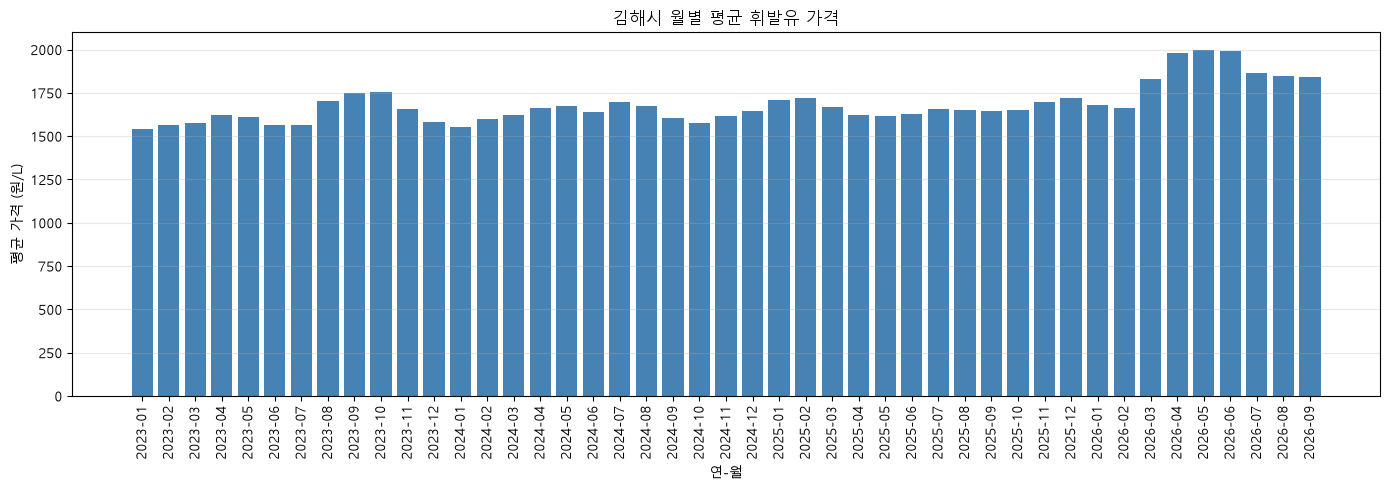

In [16]:
plt.figure(figsize=(14, 5))
plt.bar(monthly_avg["year_month"], monthly_avg["value"], color="steelblue")
plt.title("김해시 월별 평균 휘발유 가격")
plt.xlabel("연-월")
plt.ylabel("평균 가격 (원/L)")
plt.xticks(rotation=90)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../notebook/03_monthly_avg.png", dpi=150)
plt.show()

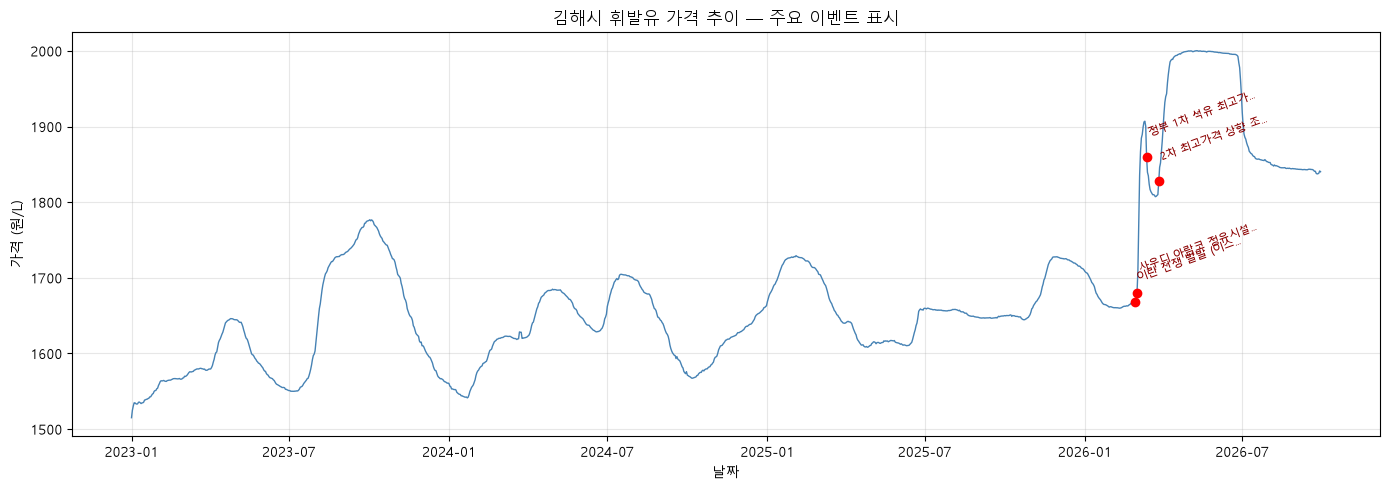

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(daily_avg["date"], daily_avg["value"], linewidth=1, color="steelblue")

# 이벤트 지점에 빨간 점과 화살표 표시
event_rows = daily_avg[daily_avg["memo"] != ""]
for _, row in event_rows.iterrows():
    plt.scatter(row["date"], row["value"], color="red", zorder=5)
    plt.annotate(row["memo"][:12] + "...", (row["date"], row["value"]),
                 textcoords="offset points", xytext=(0, 15),
                 fontsize=8, rotation=20, color="darkred")

plt.title("김해시 휘발유 가격 추이 — 주요 이벤트 표시")
plt.xlabel("날짜")
plt.ylabel("가격 (원/L)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../notebook/04_price_with_events.png", dpi=150)
plt.show()

In [18]:
final_df = daily_avg[["date", "value", "memo"]].copy()
final_df.to_csv("../data/gimhae_gasoline_final.csv", index=False, encoding="utf-8-sig")
print("최종 저장 완료! 행 개수:", len(final_df))
final_df.head()

최종 저장 완료! 행 개수: 1368


,date,value,memo
0,2023-01-01,1515.1,
1,2023-01-02,1524.9,
2,2023-01-03,1530.4,
3,2023-01-04,1534.7,
4,2023-01-05,1534.7,


In [19]:
print("최종 데이터 결측치 확인")
print(daily_avg[["date", "value", "memo"]].isna().sum())

최종 데이터 결측치 확인
date     0
value    0
memo     0
dtype: int64


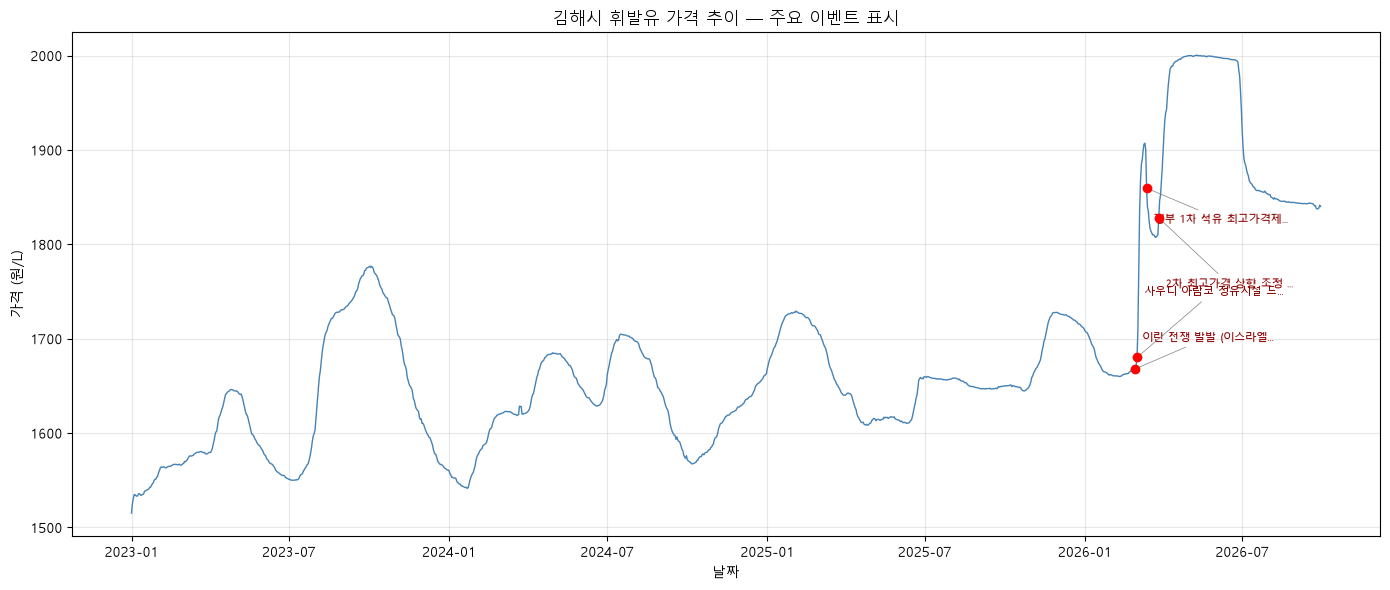

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(daily_avg["date"], daily_avg["value"], linewidth=1, color="steelblue")

event_rows = daily_avg[daily_avg["memo"] != ""].reset_index(drop=True)
offsets = [20, 45, -25, -50]  # 라벨 높이를 번갈아 배치해서 겹침 방지

for i, row in event_rows.iterrows():
    plt.scatter(row["date"], row["value"], color="red", zorder=5)
    plt.annotate(row["memo"][:14] + "...", (row["date"], row["value"]),
                 textcoords="offset points", xytext=(5, offsets[i % len(offsets)]),
                 fontsize=8, color="darkred",
                 arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.title("김해시 휘발유 가격 추이 — 주요 이벤트 표시")
plt.xlabel("날짜")
plt.ylabel("가격 (원/L)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../notebook/04_price_with_events.png", dpi=150)
plt.show()

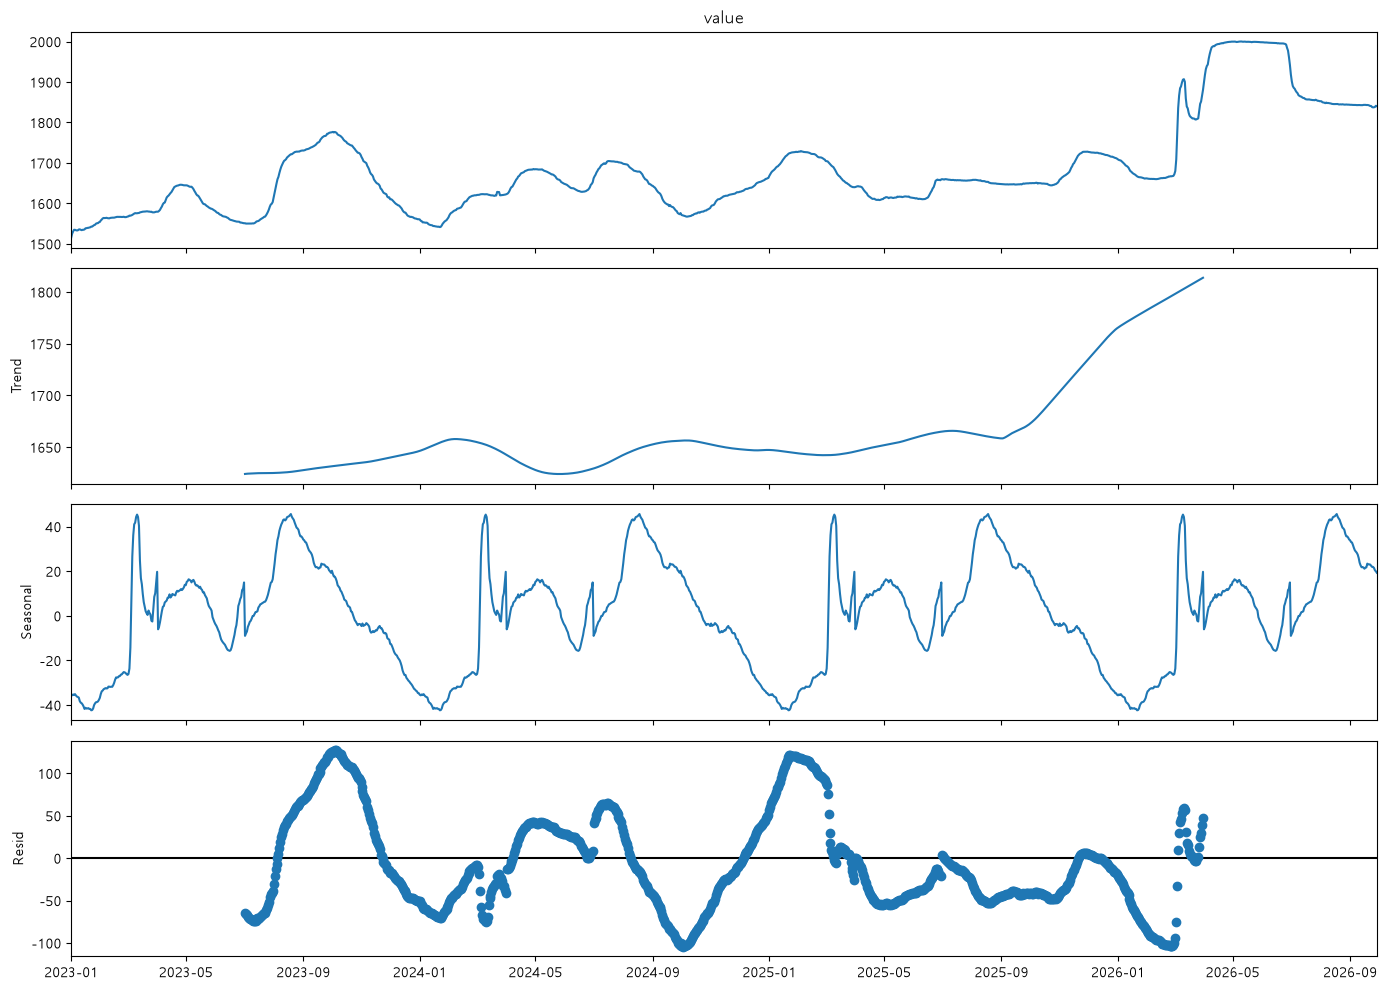

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 날짜를 인덱스로 설정하고, 일별 데이터이므로 주기(period)는 365(연간 계절성)로 지정
ts = daily_avg.set_index("date")["value"]

decomposition = seasonal_decompose(ts, model="additive", period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.savefig("../notebook/05_seasonal_decompose.png", dpi=150)
plt.show()


In [22]:
residual = decomposition.resid.dropna()
top_residuals = residual.abs().sort_values(ascending=False).head(10)
print("잔차(추세+계절성으로 설명 안 되는 부분)가 가장 큰 날짜 Top 10:")
top_residuals

잔차(추세+계절성으로 설명 안 되는 부분)가 가장 큰 날짜 Top 10:


date
2023-10-04    127.114128
2023-10-05    126.917233
2023-10-02    126.358512
2023-10-06    126.215589
2023-10-03    125.947736
2023-09-30    124.660886
2023-10-07    124.327827
2023-10-01    124.152302
2023-09-29    123.846822
2023-10-08    123.553124
Name: resid, dtype: float64

In [23]:
# 전체 잔차를 순위로 정렬하고, 2026년 3월 데이터가 몇 위인지 확인
residual_sorted = residual.abs().sort_values(ascending=False)
residual_rank = residual_sorted.reset_index()
residual_rank.columns = ["date", "abs_residual"]
residual_rank["rank"] = residual_rank.index + 1

march_2026 = residual_rank[(residual_rank["date"] >= "2026-02-25") & (residual_rank["date"] <= "2026-03-15")]
march_2026

,date,abs_residual,rank
75,2026-02-26,103.511899,76
78,2026-02-25,103.181945,79
79,2026-02-27,103.144319,80
82,2026-02-28,102.743680,83
102,2026-03-01,99.577653,103
127,2026-03-02,94.577927,128
186,2026-03-03,75.779022,187
301,2026-03-11,59.671571,302
311,2026-03-10,58.047096,312
318,2026-03-12,56.628283,319


In [24]:
import os
print(os.path.exists("../notebook/05_seasonal_decompose.png"))

True


In [25]:
# 정책 시행 전후 구간 비교
before = daily_avg[(daily_avg["date"] >= "2026-02-01") & (daily_avg["date"] <= "2026-03-12")]
after = daily_avg[(daily_avg["date"] >= "2026-03-13") & (daily_avg["date"] <= "2026-03-26")]

def summarize(period_df, label):
    return {
        "구간": label,
        "평균": round(period_df["value"].mean(), 1),
        "최고": round(period_df["value"].max(), 1),
        "최저": round(period_df["value"].min(), 1),
        "변동폭": round(period_df["value"].max() - period_df["value"].min(), 1),
        "표준편차": round(period_df["value"].std(), 1),
        "평균 일간변동(diff)": round(period_df["value"].diff().abs().mean(), 1),
    }

comparison = pd.DataFrame([
    summarize(before, "정책 시행 전 (2/1~3/12)"),
    summarize(after, "정책 시행 후 (3/13~3/26)"),
])
comparison

,구간,평균,최고,최저,변동폭,표준편차,평균 일간변동(diff)
0,정책 시행 전 (2/1~3/12),1712.0,1907.1,1659.9,247.2,90.8,6.6
1,정책 시행 후 (3/13~3/26),1818.8,1859.5,1807.3,52.2,15.5,4.2


In [26]:
before_change = daily_avg[
    (daily_avg["date"] >= "2026-02-01") & (daily_avg["date"] <= "2026-03-12")
]["weekly_change_pct"].abs().mean()

after_change = daily_avg[
    (daily_avg["date"] >= "2026-03-13") & (daily_avg["date"] <= "2026-03-26")
]["weekly_change_pct"].abs().mean()

print(f"정책 시행 전 평균 |7일 변화율|: {before_change:.2f}%")
print(f"정책 시행 후 평균 |7일 변화율|: {after_change:.2f}%")

정책 시행 전 평균 |7일 변화율|: 2.44%
정책 시행 후 평균 |7일 변화율|: 2.24%


In [27]:
# 동일 길이(14일) 구간으로 재비교: 정책 시행 직전 14일 vs 시행 후 14일
before_fair = daily_avg[(daily_avg["date"] >= "2026-02-27") & (daily_avg["date"] <= "2026-03-12")].copy()
after_fair = daily_avg[(daily_avg["date"] >= "2026-03-13") & (daily_avg["date"] <= "2026-03-26")].copy()

def summarize_fair(period_df, label):
    daily_diff = period_df["value"].diff().dropna()
    return {
        "구간": label,
        "일수": len(period_df),
        "평균": round(period_df["value"].mean(), 1),
        "최고": round(period_df["value"].max(), 1),
        "최저": round(period_df["value"].min(), 1),
        "변동폭": round(period_df["value"].max() - period_df["value"].min(), 1),
        "일간변화 표준편차": round(daily_diff.std(), 2),
        "일간변화 평균(절대값)": round(daily_diff.abs().mean(), 2),
    }

comparison_fair = pd.DataFrame([
    summarize_fair(before_fair, "정책 시행 직전 14일 (2/27~3/12)"),
    summarize_fair(after_fair, "정책 시행 후 14일 (3/13~3/26)"),
])
comparison_fair

,구간,일수,평균,최고,최저,변동폭,일간변화 표준편차,일간변화 평균(절대값)
0,정책 시행 직전 14일 (2/27~3/12),14,1804.2,1907.1,1667.4,239.7,22.86,18.94
1,정책 시행 후 14일 (3/13~3/26),14,1818.8,1859.5,1807.3,52.2,5.99,4.25


In [28]:
# 3월 최고점 이후 ~ 9월까지 가격 흐름 확인
after_peak = daily_avg[(daily_avg["date"] >= "2026-04-01") & (daily_avg["date"] <= "2026-09-29")]
peak_price = daily_avg["value"].max()
latest_price = daily_avg.iloc[-1]["value"]

print(f"3월 최고가: {peak_price}원")
print(f"9월 29일(최신) 가격: {latest_price}원")
print(f"고점 대비 하락폭: {peak_price - latest_price:.1f}원 ({(peak_price-latest_price)/peak_price*100:.1f}%)")

3월 최고가: 2000.3원
9월 29일(최신) 가격: 1840.2원
고점 대비 하락폭: 160.1원 (8.0%)


In [29]:
# 시계열 분해 결과에서 추세(trend)가 NaN인 구간 확인
trend_nan_count = decomposition.trend.isna().sum()
total_count = len(decomposition.trend)
valid_count = total_count - trend_nan_count

print(f"전체 데이터: {total_count}일")
print(f"추세 계산 불가(NaN) 구간: {trend_nan_count}일")
print(f"추세 계산 가능 구간: {valid_count}일")

# NaN이 어느 날짜부터 어느 날짜까지인지 확인
valid_trend = decomposition.trend.dropna()
print(f"\n추세가 유효한 기간: {valid_trend.index.min().date()} ~ {valid_trend.index.max().date()}")

전체 데이터: 1368일
추세 계산 불가(NaN) 구간: 364일
추세 계산 가능 구간: 1004일

추세가 유효한 기간: 2023-07-02 ~ 2026-03-31
